In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
from google.colab import drive
drive.mount('/content/drive')

!unzip "/content/drive/MyDrive/Colab Notebooks/archive.zip" -d "/content/dataset"

import os
print(os.listdir('/content/dataset'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  /content/drive/MyDrive/Colab Notebooks/archive.zip
  inflating: /content/dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  
  inflating: /content/dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  
  inflating: /content/dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv  
  inflating: /content/dataset/Monday-WorkingHours.pcap_ISCX.csv  
  inflating: /content/dataset/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  
  inflating: /content/dataset/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  
  inflating: /content/dataset/Tuesday-WorkingHours.pcap_ISCX.csv  
  inflating: /content/dataset/Wednesday-workingHours.pcap_ISCX.csv  
['Wednesday-workingHours.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Tu

In [10]:
import pandas as pd
import glob

path = "/content/dataset/*.csv"
files = glob.glob(path)

df_list = []

for file in files:
    print("Loading:", file)
    df = pd.read_csv(file, low_memory=False)
    df_list.append(df)

data = pd.concat(df_list, ignore_index=True)

print("Final Shape:", data.shape)

Loading: /content/dataset/Wednesday-workingHours.pcap_ISCX.csv
Loading: /content/dataset/Monday-WorkingHours.pcap_ISCX.csv
Loading: /content/dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: /content/dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: /content/dataset/Tuesday-WorkingHours.pcap_ISCX.csv
Loading: /content/dataset/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: /content/dataset/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: /content/dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv
Final Shape: (2830743, 79)


In [11]:
data.columns = data.columns.str.strip()

In [12]:
data['Label'].value_counts()

,count
Label,
BENIGN,2273097
DoS Hulk,231073
PortScan,158930
DDoS,128027
DoS GoldenEye,10293
FTP-Patator,7938
SSH-Patator,5897
DoS slowloris,5796
DoS Slowhttptest,5499


In [13]:
import numpy as np

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

print(data.shape)

(2827876, 79)


In [18]:
data = data.sample(n=200000, random_state=42)

In [19]:
print(data.shape)

(200000, 79)


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Label'] = le.fit_transform(data['Label'])

In [21]:
X = data.drop('Label', axis=1)
y = data['Label']

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(160000, 78) (40000, 78)


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [25]:
y_pred = rf.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.997625


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32133
           1       0.94      0.50      0.65        34
           2       1.00      1.00      1.00      1791
           3       1.00      0.97      0.98       149
           4       1.00      1.00      1.00      3250
           5       1.00      0.96      0.98        71
           6       1.00      0.99      0.99        83
           7       1.00      0.99      1.00       125
           8       0.00      0.00      0.00         1
           9       0.99      0.99      0.99      2257
          10       1.00      0.97      0.98        86
          11       0.58      0.58      0.58        12
          13       0.60      0.38      0.46         8

    accuracy                           1.00     40000
   macro avg       0.86      0.79      0.82     40000
weighted avg       1.00      1.00      1.00     40000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


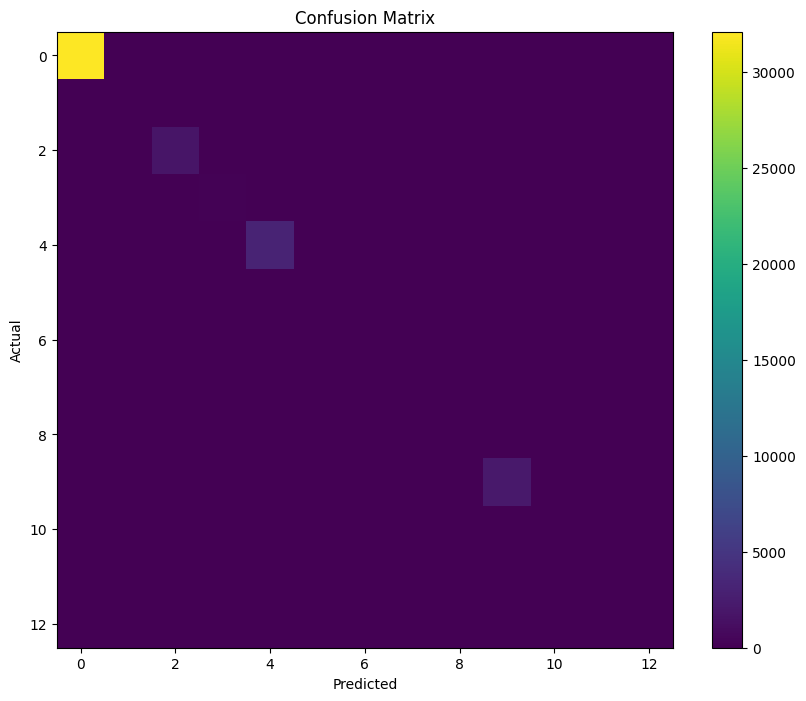

In [28]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [29]:
import numpy as np

epsilon = 0.1   # attack strength

X_test_adv = X_test + epsilon * np.sign(np.random.randn(*X_test.shape))

In [30]:
X_test_adv = np.clip(X_test_adv, X_test.min(), X_test.max())

In [31]:
y_pred_adv = rf.predict(X_test_adv)

In [32]:
from sklearn.metrics import accuracy_score

adv_accuracy = accuracy_score(y_test, y_pred_adv)
print("Accuracy After Attack:", adv_accuracy)


Accuracy After Attack: 0.84365


In [33]:
attack_success = np.mean(y_pred != y_pred_adv)
print("Attack Success Rate:", attack_success)

Attack Success Rate: 0.1553


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_adv))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91     32133
           1       0.00      0.00      0.00        34
           2       0.97      0.11      0.20      1791
           3       1.00      0.01      0.03       149
           4       0.98      0.43      0.60      3250
           5       1.00      0.01      0.03        71
           6       0.00      0.00      0.00        83
           7       0.00      0.00      0.00       125
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00      2257
          10       0.00      0.00      0.00        86
          11       0.00      0.00      0.00        12
          13       0.00      0.00      0.00         8

    accuracy                           0.84     40000
   macro avg       0.37      0.12      0.14     40000
weighted avg       0.80      0.84      0.79     40000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [35]:
epsilon = 0.1

X_train_adv = X_train + epsilon * np.sign(np.random.randn(*X_train.shape))
X_train_adv = np.clip(X_train_adv, X_train.min(), X_train.max())

In [36]:
X_train_combined = np.vstack([X_train, X_train_adv])
y_train_combined = np.hstack([y_train, y_train])

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_defended = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_defended.fit(X_train_combined, y_train_combined)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [38]:
y_pred_defended = rf_defended.predict(X_test_adv)

In [39]:
from sklearn.metrics import accuracy_score

defended_accuracy = accuracy_score(y_test, y_pred_defended)
print("Accuracy After Defense:", defended_accuracy)

Accuracy After Defense: 0.99375


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_defended))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     32133
           1       1.00      0.21      0.34        34
           2       1.00      1.00      1.00      1791
           3       0.99      0.91      0.95       149
           4       1.00      0.98      0.99      3250
           5       0.94      0.87      0.91        71
           6       0.99      0.86      0.92        83
           7       1.00      0.96      0.98       125
           8       0.00      0.00      0.00         1
           9       0.99      0.99      0.99      2257
          10       1.00      0.55      0.71        86
          11       0.00      0.00      0.00        12
          13       0.00      0.00      0.00         8

    accuracy                           0.99     40000
   macro avg       0.76      0.64      0.67     40000
weighted avg       0.99      0.99      0.99     40000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


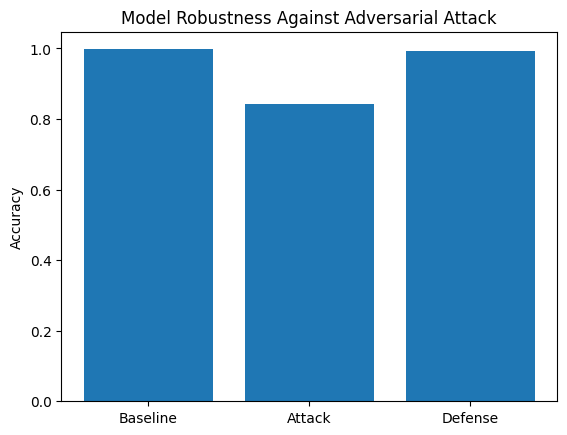

In [41]:
import matplotlib.pyplot as plt

stages = ['Baseline', 'Attack', 'Defense']
accuracy = [0.9976, 0.8436, 0.9937]

plt.figure()
plt.bar(stages, accuracy)
plt.title("Model Robustness Against Adversarial Attack")
plt.ylabel("Accuracy")
plt.show()

In [42]:
import numpy as np

def pgd_attack(X, epsilon=0.1, alpha=0.01, iterations=10):
    X_adv = X.copy()

    for i in range(iterations):
        noise = np.sign(np.random.randn(*X.shape))
        X_adv = X_adv + alpha * noise

        # project within epsilon ball
        X_adv = np.clip(X_adv, X - epsilon, X + epsilon)

    return X_adv

In [43]:
X_test_pgd = pgd_attack(X_test, epsilon=0.1, alpha=0.01, iterations=10)

In [44]:
y_pred_pgd = rf.predict(X_test_pgd)

In [45]:
from sklearn.metrics import accuracy_score

pgd_accuracy = accuracy_score(y_test, y_pred_pgd)
print("Accuracy After PGD Attack:", pgd_accuracy)

Accuracy After PGD Attack: 0.8787


In [46]:
attack_success_pgd = np.mean(y_pred != y_pred_pgd)
print("PGD Attack Success Rate:", attack_success_pgd)

PGD Attack Success Rate: 0.12025


In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_pgd))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93     32133
           1       0.00      0.00      0.00        34
           2       1.00      0.50      0.67      1791
           3       1.00      0.28      0.44       149
           4       1.00      0.63      0.77      3250
           5       1.00      0.18      0.31        71
           6       1.00      0.11      0.20        83
           7       0.00      0.00      0.00       125
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00      2257
          10       1.00      0.05      0.09        86
          11       0.00      0.00      0.00        12
          13       0.00      0.00      0.00         8

    accuracy                           0.88     40000
   macro avg       0.53      0.21      0.26     40000
weighted avg       0.83      0.88      0.84     40000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


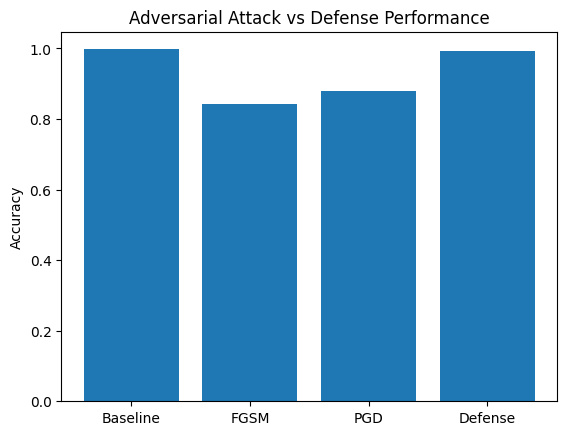

In [48]:
import matplotlib.pyplot as plt

stages = ['Baseline', 'FGSM', 'PGD', 'Defense']
accuracy = [0.9976, 0.8436, 0.8787, 0.9937]

plt.figure()
plt.bar(stages, accuracy)
plt.title("Adversarial Attack vs Defense Performance")
plt.ylabel("Accuracy")
plt.show()

In [49]:
def sanitize_input(X, clip_min=-3, clip_max=3):
    X_sanitized = np.clip(X, clip_min, clip_max)
    return X_sanitized

In [50]:
X_test_sanitized = sanitize_input(X_test_pgd)

In [51]:
y_pred_sanitized = rf.predict(X_test_sanitized)

In [52]:
from sklearn.metrics import accuracy_score

sanitized_accuracy = accuracy_score(y_test, y_pred_sanitized)
print("Accuracy After Input Sanitization:", sanitized_accuracy)

Accuracy After Input Sanitization: 0.876775


In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_sanitized))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93     32133
           1       0.00      0.00      0.00        34
           2       1.00      0.50      0.67      1791
           3       1.00      0.28      0.43       149
           4       1.00      0.61      0.76      3250
           5       1.00      0.01      0.03        71
           6       0.00      0.00      0.00        83
           7       0.00      0.00      0.00       125
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00      2257
          10       1.00      0.05      0.09        86
          11       0.00      0.00      0.00        12
          13       0.00      0.00      0.00         8

    accuracy                           0.88     40000
   macro avg       0.45      0.19      0.22     40000
weighted avg       0.83      0.88      0.84     40000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


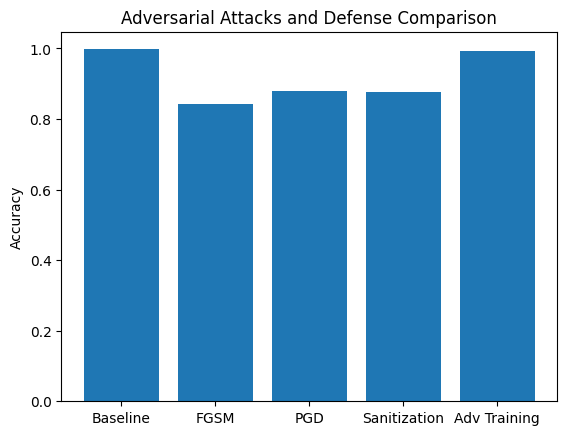

In [54]:
import matplotlib.pyplot as plt

stages = ['Baseline', 'FGSM', 'PGD', 'Sanitization', 'Adv Training']
accuracy = [0.9976, 0.8436, 0.8787, 0.8768, 0.9937]

plt.figure()
plt.bar(stages, accuracy)
plt.title("Adversarial Attacks and Defense Comparison")
plt.ylabel("Accuracy")
plt.show()

In [60]:
baseline_acc = 0.997625
fgsm_acc = 0.84365
pgd_acc = 0.8787
sanitization_acc = 0.876775
defense_acc = 0.99375

print("Baseline Accuracy:", baseline_acc)
print("FGSM Accuracy:", fgsm_acc)
print("PGD Accuracy:", pgd_acc)
print("Sanitization Accuracy:", sanitization_acc)
print("Defense Accuracy:", defense_acc)

Baseline Accuracy: 0.997625
FGSM Accuracy: 0.84365
PGD Accuracy: 0.8787
Sanitization Accuracy: 0.876775
Defense Accuracy: 0.99375


In [61]:
robustness_fgsm = fgsm_acc / baseline_acc
robustness_pgd = pgd_acc / baseline_acc

print("FGSM Robustness:", robustness_fgsm)
print("PGD Robustness:", robustness_pgd)

FGSM Robustness: 0.8456584387921313
PGD Robustness: 0.8807918807167022


In [62]:
print("FGSM Attack Success Rate:", attack_success)
print("PGD Attack Success Rate:", attack_success_pgd)

FGSM Attack Success Rate: 0.1553
PGD Attack Success Rate: 0.12025


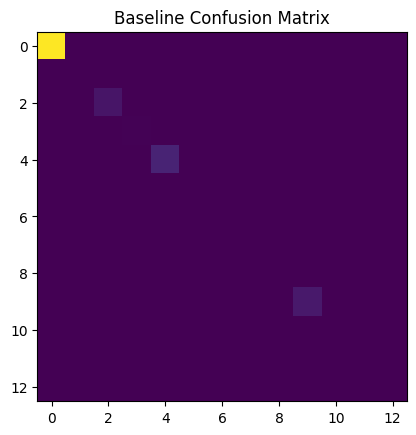

In [63]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_baseline = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm_baseline)
plt.title("Baseline Confusion Matrix")
plt.show()

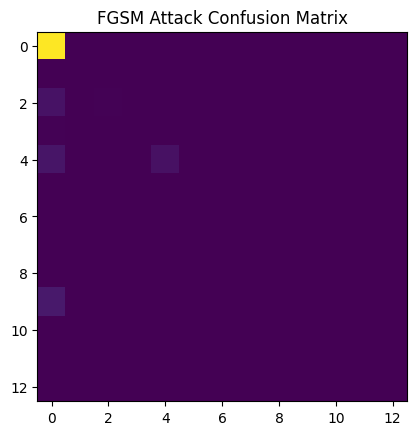

In [64]:
cm_fgsm = confusion_matrix(y_test, y_pred_adv)

plt.figure()
plt.imshow(cm_fgsm)
plt.title("FGSM Attack Confusion Matrix")
plt.show()

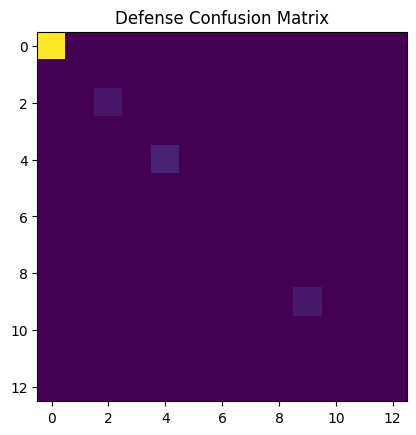

In [65]:
cm_def = confusion_matrix(y_test, y_pred_defended)

plt.figure()
plt.imshow(cm_def)
plt.title("Defense Confusion Matrix")
plt.show()

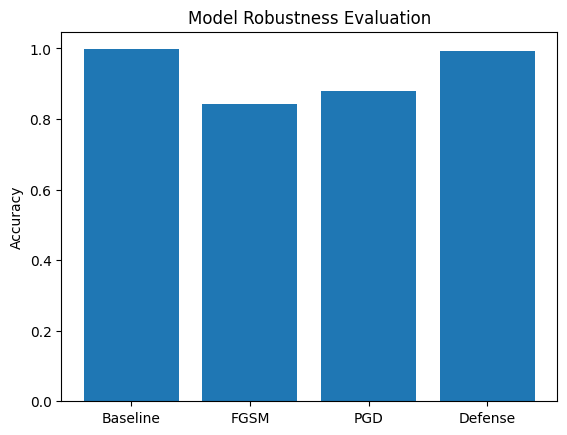

In [66]:
import matplotlib.pyplot as plt

stages = ['Baseline', 'FGSM', 'PGD', 'Defense']
accuracy_values = [baseline_acc, fgsm_acc, pgd_acc, defense_acc]

plt.figure()
plt.bar(stages, accuracy_values)
plt.title("Model Robustness Evaluation")
plt.ylabel("Accuracy")
plt.show()

In [67]:
epsilons = [0.01, 0.05, 0.1, 0.2]
fgsm_results = []

for eps in epsilons:
    X_test_adv_eps = X_test + eps * np.sign(np.random.randn(*X_test.shape))
    X_test_adv_eps = np.clip(X_test_adv_eps, X_test.min(), X_test.max())

    y_pred_eps = rf.predict(X_test_adv_eps)
    acc_eps = accuracy_score(y_test, y_pred_eps)

    fgsm_results.append(acc_eps)

    print(f"Epsilon {eps} -> Accuracy {acc_eps}")

Epsilon 0.01 -> Accuracy 0.86935
Epsilon 0.05 -> Accuracy 0.851125
Epsilon 0.1 -> Accuracy 0.842875
Epsilon 0.2 -> Accuracy 0.8314


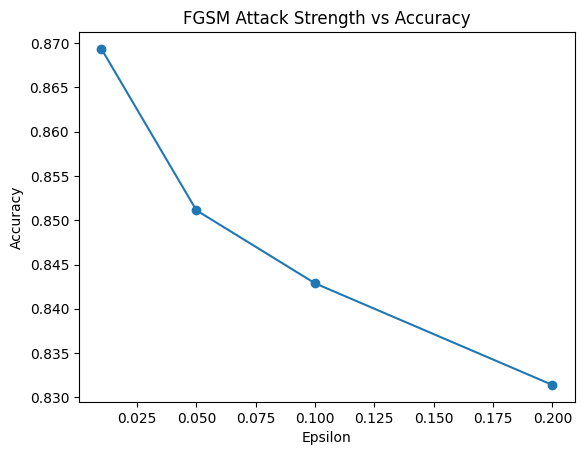

In [68]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(epsilons, fgsm_results, marker='o')
plt.title("FGSM Attack Strength vs Accuracy")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.show()

In [69]:
def_results = []

for eps in epsilons:
    X_test_adv_eps = X_test + eps * np.sign(np.random.randn(*X_test.shape))
    X_test_adv_eps = np.clip(X_test_adv_eps, X_test.min(), X_test.max())

    y_pred_def = rf_defended.predict(X_test_adv_eps)
    acc_def = accuracy_score(y_test, y_pred_def)

    def_results.append(acc_def)

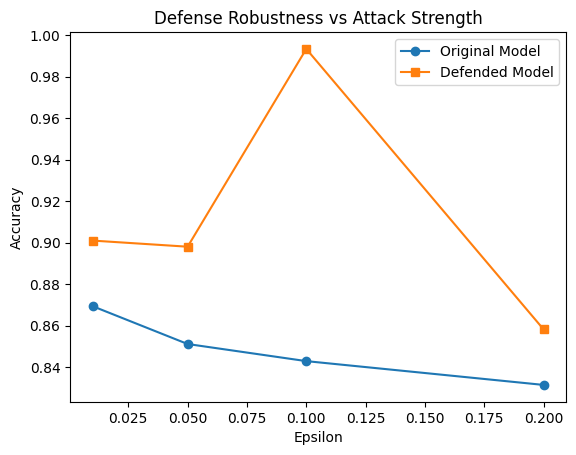

In [70]:
plt.figure()
plt.plot(epsilons, fgsm_results, marker='o', label='Original Model')
plt.plot(epsilons, def_results, marker='s', label='Defended Model')
plt.legend()
plt.title("Defense Robustness vs Attack Strength")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.show()